# Spatio-Temporal AutoEncoder no dataset UCSDPed2
Artigo: https://dl.acm.org/doi/10.1145/3123266.3123451

# Importação das bibliotecas

In [21]:
import os
import glob
import re
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, roc_curve

# Configuração

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

kaggle_dataset_folder = '/kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2'

base_folder = kaggle_dataset_folder
train_folder = os.path.join(base_folder, 'Train')
test_folder = os.path.join(base_folder, 'Test')
ground_truth_file = os.path.join(test_folder, 'UCSDped2.m')

validation_video_names = ['Train014', 'Train015', 'Train016']

window_size = 16
prediction_size = 16
img_width = 128
img_height = 128
batch_size = 8
epochs = 30
threshold_percentile = 95

print('Pasta base:', base_folder)
print('Treino:', train_folder)
print('Teste:', test_folder)
print('Ground truth:', ground_truth_file)
print('Vídeos fixos de validação:', validation_video_names)

Pasta base: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2
Treino: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train
Teste: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test
Ground truth: /kaggle/input/datasets/karthiknm1/ucsd-anomaly-detection-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/UCSDped2.m
Vídeos fixos de validação: ['Train014', 'Train015', 'Train016']


# Pré-processamento

In [23]:
# Funções auxiliares
def redimensiona_frame(frame, largura=128, altura=128):
    if len(frame.shape) == 3:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return cv2.resize(frame, (largura, altura), interpolation=cv2.INTER_AREA)

def normalizar_canal(frame):
    frame = frame.astype(np.float32) / 255.0
    return np.expand_dims(frame, axis=-1)

In [24]:
def get_folders(dataset, prefix):
    folders = []
    pattern = re.compile(rf'^{prefix}\d+$')

    for name in sorted(os.listdir(dataset)):
        path = os.path.join(dataset, name)
        if os.path.isdir(path) and pattern.match(name):
            folders.append(path)

    return folders

def get_frames(video_folder):
    return sorted(glob.glob(os.path.join(video_folder, '*.tif')))

def preprocess(frame_path):
    frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE)
    frame = redimensiona_frame(frame, largura=img_width, altura=img_height)
    frame = normalizar_canal(frame)
    return frame.astype(np.float32)

def load_video(video_folder):
    frame_paths = get_frames(video_folder)
    if not frame_paths:
        raise ValueError(f'Nenhum frame .tif encontrado em: {video_folder}')

    frames = []
    for frame_path in frame_paths:
        frames.append(preprocess(frame_path))
    return np.asarray(frames, dtype=np.float32)

def create_windows(video, window_size=16, prediction_size=16):
    x = []
    y_reconstruction = []
    y_prediction = []
    frame_ids = []

    total_size = window_size + prediction_size
    for start in range(len(video) - total_size + 1):
        input_window = video[start:start + window_size]
        future_window = video[start + window_size:start + total_size]

        x.append(input_window)
        y_reconstruction.append(input_window)
        y_prediction.append(future_window)
        frame_ids.append(start + window_size - 1)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y_reconstruction, dtype=np.float32),
        np.asarray(y_prediction, dtype=np.float32),
        np.asarray(frame_ids, dtype=np.int32)
    )

In [25]:
all_train_videos = get_folders(train_folder, 'Train')
test_videos = get_folders(test_folder, 'Test')

val_videos = [
    video_folder
    for video_folder in all_train_videos
    if os.path.basename(video_folder) in validation_video_names
]
train_videos = [
    video_folder
    for video_folder in all_train_videos
    if os.path.basename(video_folder) not in validation_video_names
]

if len(val_videos) != len(validation_video_names):
    found_names = [os.path.basename(video_folder) for video_folder in val_videos]
    raise ValueError(f'Vídeos de validação não encontrados. Esperado: {validation_video_names}. Encontrado: {found_names}')

print('Vídeos normais disponíveis:', len(all_train_videos))
print('Vídeos de treino:', len(train_videos), [os.path.basename(video_folder) for video_folder in train_videos])
print('Vídeos de validação:', len(val_videos), [os.path.basename(video_folder) for video_folder in val_videos])
print('Vídeos de teste:', len(test_videos))
print('Frames no primeiro vídeo de treino:', len(get_frames(train_videos[0])))
print('Frames no primeiro vídeo de validação:', len(get_frames(val_videos[0])))
print('Frames no primeiro vídeo de teste:', len(get_frames(test_videos[0])))

Vídeos normais disponíveis: 16
Vídeos de treino: 13 ['Train001', 'Train002', 'Train003', 'Train004', 'Train005', 'Train006', 'Train007', 'Train008', 'Train009', 'Train010', 'Train011', 'Train012', 'Train013']
Vídeos de validação: 3 ['Train014', 'Train015', 'Train016']
Vídeos de teste: 12
Frames no primeiro vídeo de treino: 120
Frames no primeiro vídeo de validação: 150
Frames no primeiro vídeo de teste: 180


In [26]:
def load_windows(video_folders):
    data = []
    reconstruction_targets = []
    prediction_targets = []

    for video_folder in video_folders:
        video = load_video(video_folder)
        x, y_rec, y_pred, _ = create_windows(video, window_size, prediction_size)

        data.append(x)
        reconstruction_targets.append(y_rec)
        prediction_targets.append(y_pred)

    return (
        np.concatenate(data, axis=0),
        np.concatenate(reconstruction_targets, axis=0),
        np.concatenate(prediction_targets, axis=0)
    )

x_train, y_rec_train, y_pred_train = load_windows(train_videos)
x_val, y_rec_val, y_pred_val = load_windows(val_videos)

train_order = np.random.default_rng(SEED).permutation(len(x_train))
x_train = x_train[train_order]
y_rec_train = y_rec_train[train_order]
y_pred_train = y_pred_train[train_order]

print('Entradas de treino:', x_train.shape)
print('Alvo de reconstrução - treino:', y_rec_train.shape)
print('Alvo de predição - treino:', y_pred_train.shape)
print('Entradas de validação:', x_val.shape)
print('Alvo de reconstrução - validação:', y_rec_val.shape)
print('Alvo de predição - validação:', y_pred_val.shape)
print('Permutação fixa do treino - seed:', SEED)
print('Primeiros índices da permutação:', train_order[:10])

Entradas de treino: (1697, 16, 128, 128, 1)
Alvo de reconstrução - treino: (1697, 16, 128, 128, 1)
Alvo de predição - treino: (1697, 16, 128, 128, 1)
Entradas de validação: (357, 16, 128, 128, 1)
Alvo de reconstrução - validação: (357, 16, 128, 128, 1)
Alvo de predição - validação: (357, 16, 128, 128, 1)
Permutação fixa do treino - seed: 42
Primeiros índices da permutação: [ 352  911  818 1216  304  282 1615  476  505 1590]


# Anotações do conjunto de teste

In [27]:
def parse_ground_truth(file_path):
    with open(file_path, 'r') as file:
        text = file.read()

    intervals = re.findall(r'gt_frame\s*=\s*\[(.*?)\]', text)
    ground_truth = []

    for interval in intervals:
        frames = []
        parts = interval.split(',')

        for part in parts:
            part = part.strip()
            if ':' in part:
                start, end = part.split(':')
                frames.extend(range(int(start), int(end) + 1))
            elif part:
                frames.append(int(part))

        ground_truth.append(sorted(set(frames)))

    return ground_truth

def create_labels(video_folder, anomaly_frames):
    total_frames = len(get_frames(video_folder))
    labels = np.zeros(total_frames, dtype=np.uint8)

    for frame in anomaly_frames:
        index = frame - 1
        if 0 <= index < total_frames:
            labels[index] = 1

    return labels

ground_truth = parse_ground_truth(ground_truth_file)
print('Vídeos anotados:', len(ground_truth))
print('Primeira anotação:', ground_truth[0][:10], '...')

Vídeos anotados: 12
Primeira anotação: [61, 62, 63, 64, 65, 66, 67, 68, 69, 70] ...


# Visualização dos dados

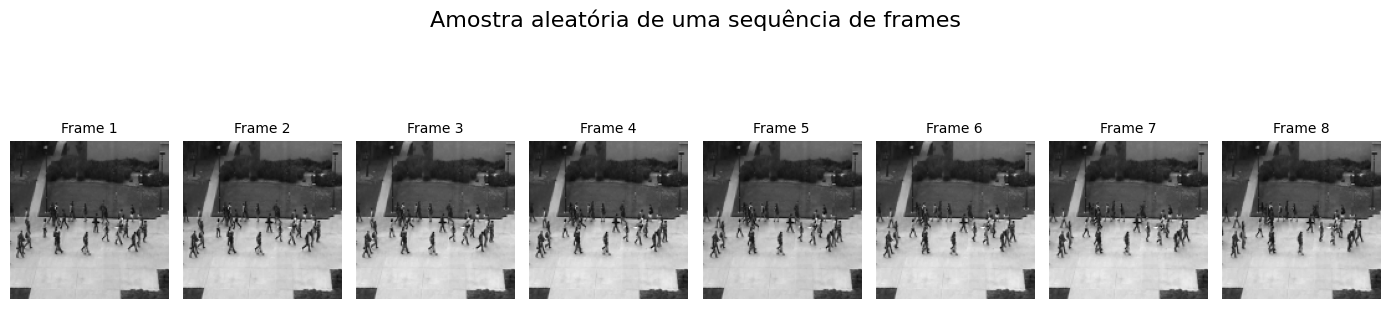

In [28]:
def show_random_sequence(data, n=8):
    index = random.randint(0, len(data) - 1)
    sequence = data[index]

    plt.figure(figsize=(14, 4))
    plt.suptitle('Amostra aleatória de uma sequência de frames', fontsize=16)

    for i in range(min(n, len(sequence))):
        plt.subplot(1, n, i + 1)
        plt.imshow(sequence[i, :, :, 0], cmap='gray')
        plt.title(f'Frame {i + 1}', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_random_sequence(x_train)

# Modelo proposto

In [29]:
def loss_reconstrucao(y_true, y_pred):
    erro_quadratico = tf.square(y_true - y_pred)
    loss_por_amostra = tf.reduce_sum(erro_quadratico, axis=[1, 2, 3, 4])
    volume_clipe = tf.cast(tf.reduce_prod(tf.shape(y_true)[1:]), tf.float32)
    return tf.reduce_mean(loss_por_amostra / volume_clipe)


def loss_reconstrucao_predicao(T=16):
    pesos_lista = [float(T - t) for t in range(1, T + 1)]
    pesos_tensor = tf.reshape(tf.constant(pesos_lista, dtype=tf.float32), (1, T, 1, 1, 1))
    constante_t2 = 1.0 / (T ** 2)

    def loss(y_true, y_pred):
        erro_quadratico = tf.square(y_true - y_pred)
        erro_ponderado = erro_quadratico * pesos_tensor
        loss_por_amostra = tf.reduce_sum(erro_ponderado, axis=[1, 2, 3, 4])
        volume_clipe = tf.cast(tf.reduce_prod(tf.shape(y_true)[1:]), tf.float32)
        return constante_t2 * tf.reduce_mean(loss_por_amostra / volume_clipe)

    return loss


def build_model():
    def conv3d_layer(inputs, kernels, last=False):
        x = tf.keras.layers.Conv3D(
            filters=kernels, 
            kernel_size=(3, 3, 3), 
            strides=(1, 1, 1), 
            padding='same', 
            use_bias=False
        )(inputs)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.LeakyReLU(negative_slope=0.1)(x)
        if (not last):
            x = tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(x)
        return x

    inputs = tf.keras.layers.Input(
        shape=(window_size, img_height, img_width, 1),
        name='input_window'
    )

    def deconv3d_layer(inputs, kernels):
        x = tf.keras.layers.Conv3DTranspose(
            filters=kernels,
            kernel_size=(3, 3, 3),
            strides=(2, 2, 2),
            padding='same',
            use_bias=False
        )(inputs)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.LeakyReLU(negative_slope=0.1)(x)
        return x

    def conv3d_reconstruction_layer(inputs, kernels):
        x = tf.keras.layers.Conv3D(
            filters=kernels, 
            kernel_size=(3, 3, 3), 
            strides=(1, 1, 1), 
            padding='same', 
            use_bias=True,
            activation='sigmoid'
        )(inputs)
        return x
        
    # Encoder
    x = conv3d_layer(inputs, kernels=32)  # Camada 1
    x = conv3d_layer(x, kernels=48)       # Camada 2
    x = conv3d_layer(x, kernels=64)       # Camada 3
    x = conv3d_layer(x, kernels=64, last=True)       # Camada 4
    print(f"Shape do bottleneck: {x.shape}. Deve ser (2,16,16,64)")
    
    # Decoder de reconstrução
    reconstruction = deconv3d_layer(x, kernels=48)   # Camada 1
    reconstruction = deconv3d_layer(reconstruction, kernels=32)   # Camada 2
    reconstruction = deconv3d_layer(reconstruction, kernels=32)   # Camada 3
    reconstruction = conv3d_reconstruction_layer(reconstruction, kernels=1)
    print(f"Shape da saída da reconstrução: {reconstruction.shape}. Deve ser (16,128,128,1)")

    # Decoder de predição dos próximos frames
    prediction = deconv3d_layer(x, kernels=48)   # Camada 1
    prediction = deconv3d_layer(prediction, kernels=32)   # Camada 2
    prediction = deconv3d_layer(prediction, kernels=32)   # Camada 3
    prediction = conv3d_reconstruction_layer(prediction, kernels=1)
    print(f"Shape da predição dos frames seguintes: {prediction.shape}. Deve ser (16,128,128,1)")

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[reconstruction, prediction]
    )
    loss_predicao = loss_reconstrucao_predicao(T=window_size)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=[loss_reconstrucao, loss_predicao],
        loss_weights=[1.0, 1.0]
    )
    return model

model = build_model()
model.summary()

Shape do bottleneck: (None, 2, 16, 16, 64). Deve ser (2,16,16,64)
Shape da saída da reconstrução: (None, 16, 128, 128, 1). Deve ser (16,128,128,1)
Shape da predição dos frames seguintes: (None, 16, 128, 128, 1). Deve ser (16,128,128,1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_window        │ (None, 16, 128,   │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 128,   │        864 │ input_window[0][… │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │        128 │ conv3d_6[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 16, 128,   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 8, 64, 64, │          0 │ leaky_re_lu_10[0… │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 8, 64, 64, │     41,472 │ max_pooling3d_3[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        192 │ conv3d_7[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 4, 32, 32, │          0 │ leaky_re_lu_11[0… │
│ (MaxPooling3D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_8 (Conv3D)   │ (None, 4, 32, 32, │     82,944 │ max_pooling3d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 32, 32, │        256 │ conv3d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 4, 32, 32, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_5     │ (None, 2, 16, 16, │          0 │ leaky_re_lu_12[0… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_9 (Conv3D)   │ (None, 2, 16, 16, │    110,592 │ max_pooling3d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 16, 16, │        256 │ conv3d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 2, 16, 16, │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_transpose_6  │ (None, 4, 32, 32, │     82,944 │ leaky_re_lu_13[0

 Total params: 543,458 (2.07 MB)

 Trainable params: 542,594 (2.07 MB)

 Non-trainable params: 864 (3.38 KB)

# Divisão em treino, validação e treinamento

In [30]:
print('Divisão fixa por vídeo')
print('Treino:', [os.path.basename(video_folder) for video_folder in train_videos])
print('Validação:', [os.path.basename(video_folder) for video_folder in val_videos])
print('Teste:', [os.path.basename(video_folder) for video_folder in test_videos])
print('Shape de treino:', x_train.shape)
print('Shape de validação:', x_val.shape)

Divisão fixa por vídeo
Treino: ['Train001', 'Train002', 'Train003', 'Train004', 'Train005', 'Train006', 'Train007', 'Train008', 'Train009', 'Train010', 'Train011', 'Train012', 'Train013']
Validação: ['Train014', 'Train015', 'Train016']
Teste: ['Test001', 'Test002', 'Test003', 'Test004', 'Test005', 'Test006', 'Test007', 'Test008', 'Test009', 'Test010', 'Test011', 'Test012']
Shape de treino: (1697, 16, 128, 128, 1)
Shape de validação: (357, 16, 128, 128, 1)


In [31]:
history = model.fit(
    x_train,
    [y_rec_train, y_pred_train],
    validation_data=(x_val, [y_rec_val, y_pred_val]),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,
    verbose=1
)

'''history = model.fit(
    x_train,
    y_rec_train,
    validation_data=(x_val, y_rec_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,
    verbose=1
)'''

Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 102s 420ms/step - conv3d_10_loss: 0.0090 - conv3d_11_loss: 3.0680e-04 - loss: 0.0094 - val_conv3d_10_loss: 0.0355 - val_conv3d_11_loss: 0.0012 - val_loss: 0.0366
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 80s 378ms/step - conv3d_10_loss: 0.0024 - conv3d_11_loss: 9.2544e-05 - loss: 0.0025 - val_conv3d_10_loss: 0.0178 - val_conv3d_11_loss: 6.3027e-04 - val_loss: 0.0184
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 79s 371ms/step - conv3d_10_loss: 0.0019 - conv3d_11_loss: 7.5969e-05 - loss: 0.0020 - val_conv3d_10_loss: 0.0022 - val_conv3d_11_loss: 8.0842e-05 - val_loss: 0.0023
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - conv3d_10_loss: 0.0017 - conv3d_11_loss: 6.5547e-05 - loss: 0.0017 - val_conv3d_10_loss: 0.0013 - val_conv3d_11_loss: 5.1881e-05 - val_loss: 0.0014
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - conv3d_10_loss: 0.0015 - conv3d_11_loss: 5.8012e-05 - loss: 0.0015 - val_conv3d_10_loss: 0.0012 - val_conv3d_11_loss: 4.6340e-

'history = model.fit(\n    x_train,\n    y_rec_train,\n    validation_data=(x_val, y_rec_val),\n    epochs=epochs,\n    batch_size=batch_size,\n    shuffle=False,\n    verbose=1\n)'

# Visualização da reconstrução

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def visualizar_par_frames_kaggle(original, gerado, titulo_gerado="Modelo", idx=0):
    """
    Renderiza um player lado a lado comparando um par de sequências de frames.
    
    Parâmetros:
    - original: Array/Tensor original real (T, H, W, C) ou (T, H, W)
    - gerado: Array/Tensor gerado pelo modelo (T, H, W, C) ou (T, H, W)
    - titulo_gerado: Título a ser exibido no painel da direita
    - idx: Índice do exemplo para exibição no título principal
    """
    # Garantir intervalo [0, 1] para o Matplotlib
    original = np.clip(original, 0, 1)
    gerado = np.clip(gerado, 0, 1)
    
    # Remover dimensão de canal se for Grayscale (Canais = 1)
    if original.shape[-1] == 1:
        original = np.squeeze(original, axis=-1)
        gerado = np.squeeze(gerado, axis=-1)
        cmap = 'gray'
    else:
        cmap = None

    num_frames = original.shape[0]

    # Configurar a estrutura dos eixos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Análise de Sequência - Index: {idx}", fontsize=12)
    
    ax1.set_title("Original Real")
    ax2.set_title(titulo_gerado)
    
    ax1.axis('off')
    ax2.axis('off')

    # Inicializar com o primeiro frame
    im1 = ax1.imshow(original[0], cmap=cmap)
    im2 = ax2.imshow(gerado[0], cmap=cmap)
    plt.tight_layout()

    # Função de atualização frame a frame pura e direta
    def update(frame_idx):
        im1.set_data(original[frame_idx])
        im2.set_data(gerado[frame_idx])
        return [im1, im2]

    # Criar animação estável
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=num_frames, 
        interval=150, 
        blit=True
    )
    
    plt.close() 
    return HTML(anim.to_html5_video())

In [35]:
# 1. Escolhe o índice do exemplo de teste/validação
idx_teste = np.random.randint(0, len(x_val))
dados_entrada = x_val[idx_teste : idx_teste + 1]

# 2. Roda a inferência no modelo para pegar as duas saídas independentes
saidas = model.predict(dados_entrada)
tensor_reconstruido = saidas[0][0] # Ramificação da Reconstrução
tensor_predito = saidas[1][0]      # Ramificação da Predição

visualizar_par_frames_kaggle(
    original=x_val[idx_teste], 
    gerado=tensor_reconstruido, 
    titulo_gerado="Reconstrução", 
    idx=idx_teste
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step


In [36]:
visualizar_par_frames_kaggle(
    original=y_pred_val[idx_teste], 
    gerado=tensor_predito, 
    titulo_gerado="Predição (Futuro)", 
    idx=idx_teste
)

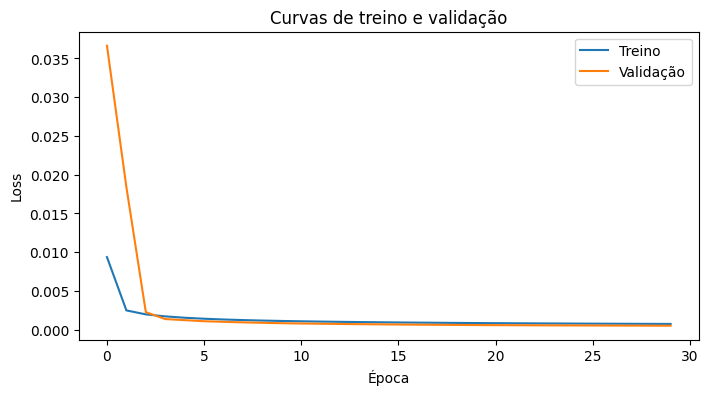

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curvas de treino e validação')
plt.legend()
plt.show()

# Avaliação

In [38]:
def normalize_scores(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())


def create_reconstruction_windows(video, window_size=16):
    if len(video) < window_size:
        raise ValueError(f'O vídeo precisa ter pelo menos {window_size} frames.')

    windows = []
    start_ids = []

    for start in range(len(video) - window_size + 1):
        windows.append(video[start:start + window_size])
        start_ids.append(start)

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(start_ids, dtype=np.int32)
    )


def anomaly_score(video_folder):
    video = load_video(video_folder)
    x, start_ids = create_reconstruction_windows(video, window_size)

    reconstruction_pred, _ = model.predict(x, batch_size=batch_size, verbose=0)
    reconstruction_error = np.mean((reconstruction_pred - x) ** 2, axis=(2, 3, 4))

    scores = np.zeros(len(video), dtype=np.float32)
    counts = np.zeros(len(video), dtype=np.float32)

    for start, frame_errors in zip(start_ids, reconstruction_error):
        stop = start + window_size
        scores[start:stop] += frame_errors
        counts[start:stop] += 1

    if np.any(counts == 0):
        raise RuntimeError('Existem frames sem score de reconstrução.')

    return scores / counts

In [39]:
validation_scores = []

for video_folder in val_videos:
    raw_scores = anomaly_score(video_folder)
    scores = normalize_scores(raw_scores)
    validation_scores.extend(scores)

validation_scores = np.asarray(validation_scores, dtype=np.float32)
classification_threshold = np.percentile(validation_scores, threshold_percentile)

y_true = []
y_scores = []
video_results = []

for video_folder, anomaly_frames in zip(test_videos, ground_truth):
    labels = create_labels(video_folder, anomaly_frames)
    raw_scores = anomaly_score(video_folder)
    scores = normalize_scores(raw_scores)

    y_true.extend(labels)
    y_scores.extend(scores)
    video_results.append((os.path.basename(video_folder), labels, scores))

y_true = np.asarray(y_true)
y_scores = np.asarray(y_scores, dtype=np.float32)
y_pred = (y_scores >= classification_threshold).astype(np.uint8)

auroc = roc_auc_score(y_true, y_scores)

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_index] + fnr[eer_index]) / 2
eer_threshold = roc_thresholds[eer_index]

auprc = average_precision_score(y_true, y_scores)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

print('Validation threshold percentile:', threshold_percentile)
print('Classification threshold:', classification_threshold)
print('AUROC:', auroc)
print('EER:', eer)
print('EER threshold:', eer_threshold)
print('AUPRC:', auprc)
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)
print('Accuracy:', accuracy)

Validation threshold percentile: 95
Classification threshold: 0.84198815
AUROC: 0.8102094284718125
EER: 0.2723592635305477
EER threshold: 0.35406962
AUPRC: 0.949282958486556
Precision: 0.9864864864864865
Recall: 0.08859223300970874
F1-score: 0.16258351893095768
Accuracy: 0.2517412935323383


# Visualização dos resultados

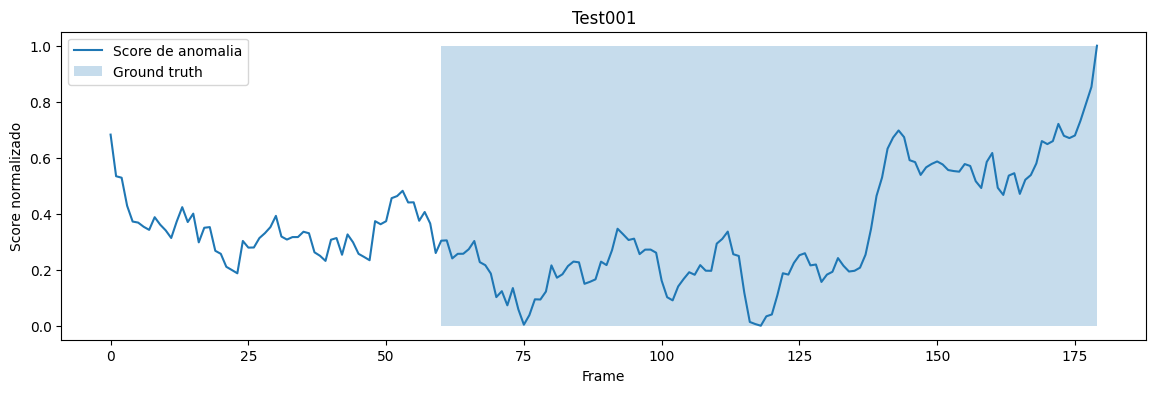

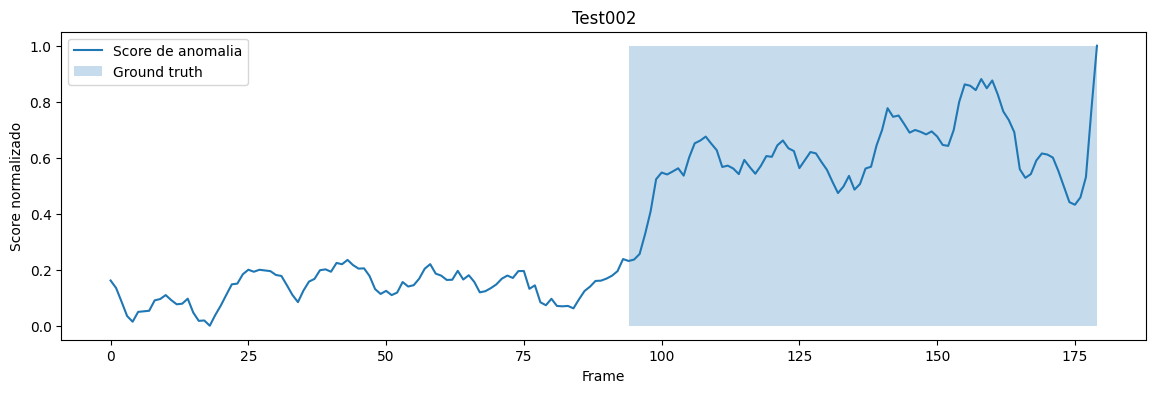

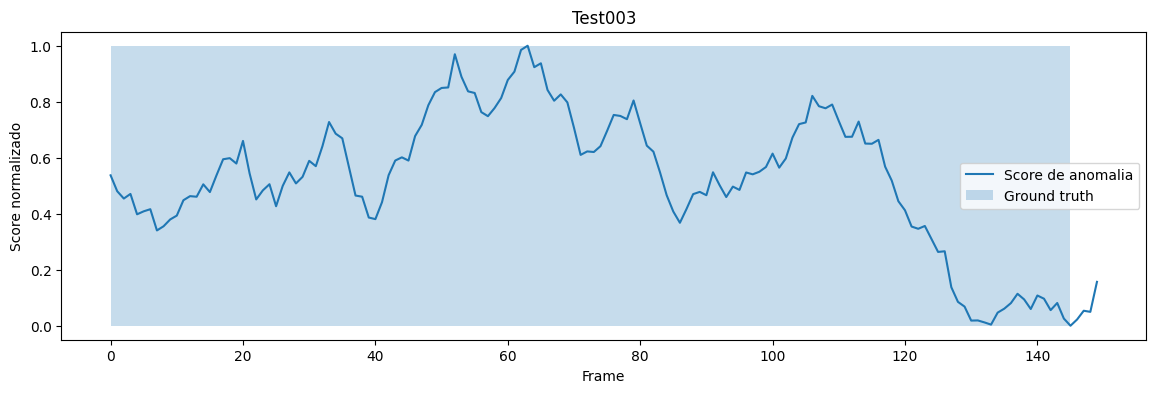

In [40]:
def show_video_result(video_name, labels, scores):
    plt.figure(figsize=(14, 4))
    plt.plot(scores, label='Score de anomalia')
    plt.fill_between(
        np.arange(len(labels)),
        0,
        1,
        where=labels.astype(bool),
        alpha=0.25,
        label='Ground truth'
    )
    plt.title(video_name)
    plt.xlabel('Frame')
    plt.ylabel('Score normalizado')
    plt.legend()
    plt.show()

for video_name, labels, scores in video_results[:3]:
    show_video_result(video_name, labels, scores)